In [27]:
import numpy as np
import matplotlib.pyplot as plt
import math


def e_exact(x, y):
    return np.exp(-2*np.sin(x))


def e_appx(step):
    # Define parameters
    h = step  # step size
    x_start, x_end = 0, 10*math.pi
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    
    # Initial condition
    y_values[0] = 1  # y(0) = 1
    # Function representing dy/dx = -2y cos(x)
    def f(x, y):
        return -2 * y * math.cos(x)

    
    def find_nearest(array, value):
        idx = (np.abs(array - value)).argmin()
        return idx
    
    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    
    y_err = np.abs(e_exact(x_values, y_values) - y_values)
    err_15 = y_values[find_nearest(x_values, 15)]
    
    # Plot the results
    plt.plot(x_values, y_values, label=f"step={step:.2f}")
    plt.plot(x_values, y_err, label=f"local error")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title("Approximation of dy/dx = -2y*cos(x) using Euler's Method")
    plt.legend()
    plt.show()
    
    
    return y_err, err_15
    

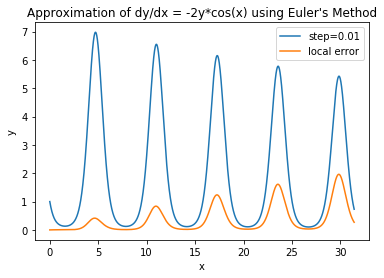

Total Error: 1159.4491243325083


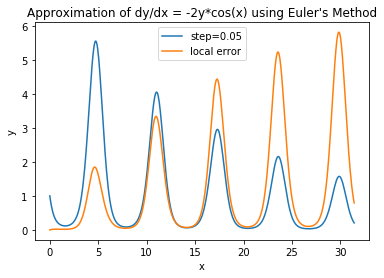

Total Error: 792.3695267968764


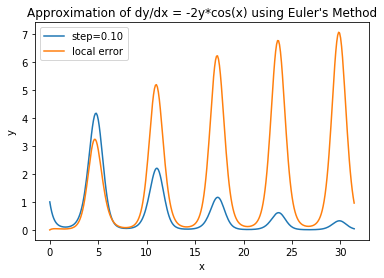

Total Error: 547.4060840192333


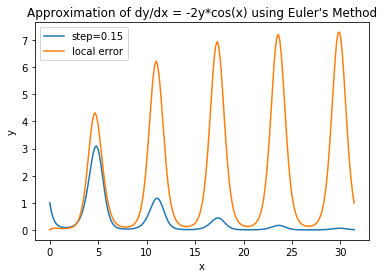

Total Error: 410.2791267266061


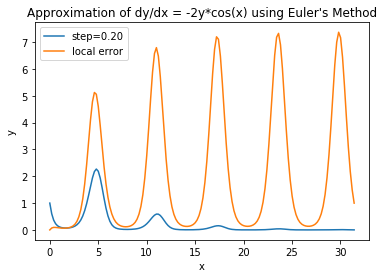

Total Error: 326.5882086383206


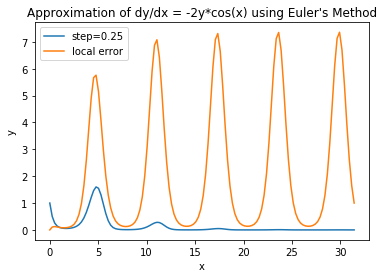

Total Error: 268.83768096675595


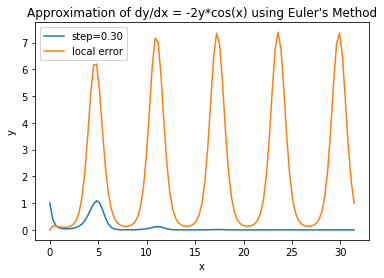

Total Error: 228.49495029467946


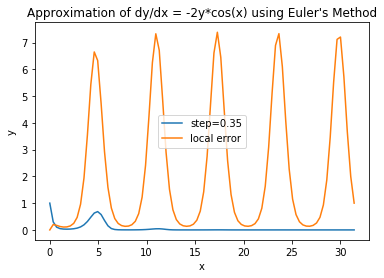

Total Error: 198.40664348644094


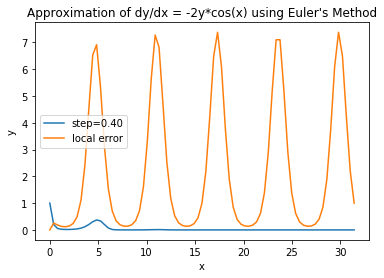

Total Error: 175.68727603450566


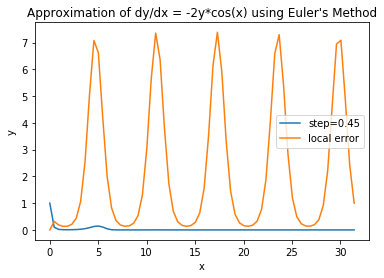

Total Error: 156.5402855687373


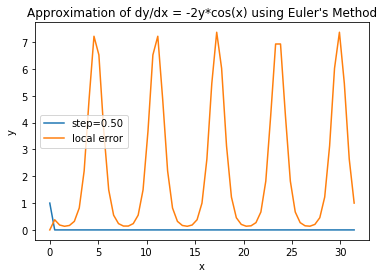

Total Error: 141.33428874483616


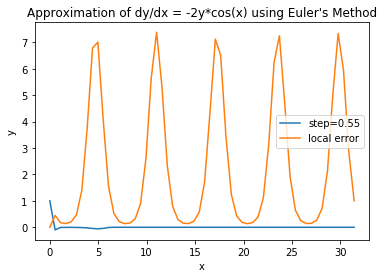

Total Error: 130.2441512384714


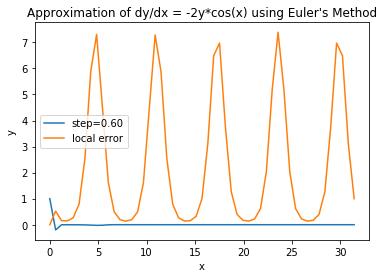

Total Error: 118.82169512035189


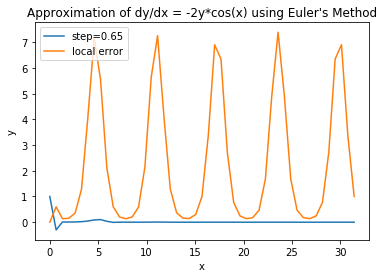

Total Error: 109.39261349260798


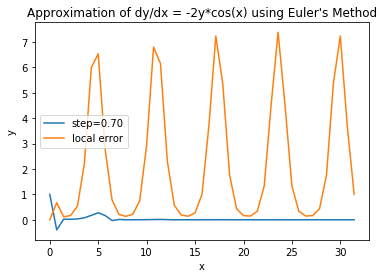

Total Error: 99.91188063388981


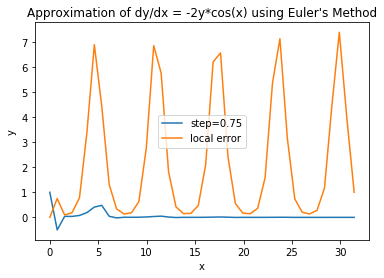

Total Error: 92.53464480755862


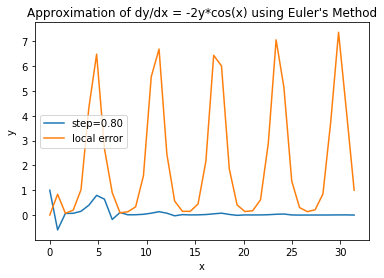

Total Error: 86.85921127392182


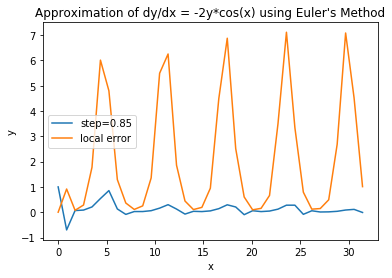

Total Error: 78.67977536786523


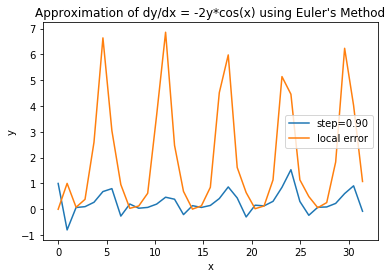

Total Error: 68.92935039073863


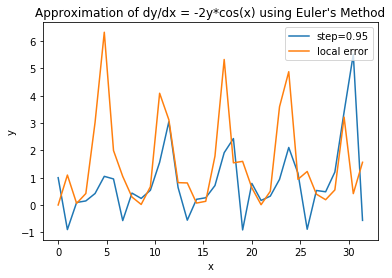

Total Error: 52.3602265383176


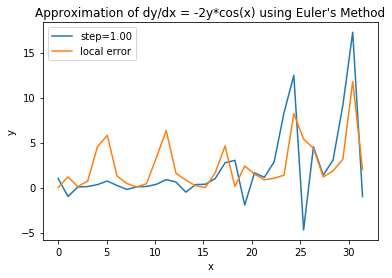

Total Error: 78.30910383000734


In [29]:
# one plot for each step size
hs = []
avg_err = []
err_15 = []

for i in [0.01, *np.arange(0.05, 1.05, 0.05)]:
    err, e15 = e_appx(i)
    hs.append(i)
    avg_err.append(np.mean(err))
    err_15.append(e15)
    print(f"Total Error: {sum(err)}")
    print(f"================================")
    


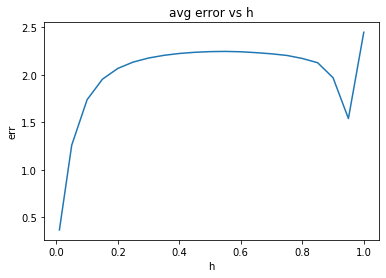

In [32]:
# average error between runs vs h

plt.plot(hs, avg_err)
plt.xlabel('h')
plt.ylabel('err')
plt.title("avg error vs h")
plt.show()

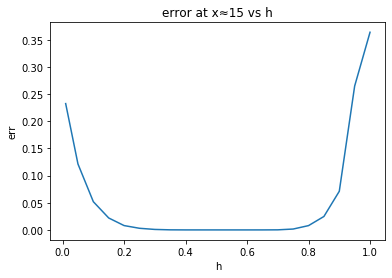

In [33]:
# error at 15 runs vs h

plt.plot(hs, err_15)
plt.xlabel('h')
plt.ylabel('err')
plt.title("error at x≈15 vs h")
plt.show()

In [ ]:
""" Discussion



Addendum:

λ=−2cos(x)

Stable when λ > 0

Implies stability when:

cos(x)>0

"""